***RELOAD DATA & LIBRARY***

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    f1_score,
    roc_auc_score
)
# for save and load model
import joblib
import json
import os

#Show all columns, without hiding any
pd.set_option('display.max_columns', None)

In [74]:
#Load the dataset
path = "../Data/data_featured.csv"
df = pd.read_csv(path)

#Quick look at the data
df.head()

,track_id,track_name,track_number,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min,release_year,release_month,is_hit,duration_level,track_duration_sq,is_short_song,song_age,is_recent_song,release_season,artist_followers_log,artist_is_popular,artist_power_score,is_single_album,is_lead_track,track_position_ratio,genre_count,genre_pop,genre_rap,genre_rock,genre_hip_hop,genre_dance,genre_latin,artist_pop_x_followers,duration_x_artist_pop,explicit_x_artist_pop
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55,2025,10,0,Short,2.4025,1,1,1,Fall,14.849699,1,1143.426808,0,0,0.444444,1,0,0,0,0,0,0,1143.426808,119.35,77
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07,2025,10,0,Medium,9.4249,0,1,1,Fall,14.675628,0,939.240212,1,1,1.000000,2,0,0,0,1,0,0,939.240212,196.48,64
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,True,Riff Raff,48,193302,unknown,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55,2025,10,0,Medium,6.5025,0,1,1,Fall,12.172014,0,584.256681,1,1,1.000000,1,0,0,0,0,0,0,584.256681,122.40,48
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69,2025,10,0,Short,2.8561,1,1,1,Fall,14.850015,1,1143.451140,0,0,0.888889,1,0,0,0,0,0,0,1143.451140,130.13,77
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39,2025,10,0,Short,5.7121,1,1,1,Fall,9.069122,0,435.317874,1,0,1.000000,1,0,0,0,0,0,0,435.317874,114.72,48


***MODEL PREPROCESSING***

In [75]:
import pandas as pd

df_featured = pd.read_csv("../Data/data_featured.csv")

In [76]:
# 1. DEFINE X AND y

target_col = 'is_hit'

y = df_featured[target_col]

drop_cols = [
    'is_hit',
    'track_popularity',
    'track_id',
    'track_name',
    'artist_name',
    'artist_genres',
    'album_name',
    'album_release_date'
]

X = df_featured.drop(columns=drop_cols, errors='ignore')

print("Feature matrix X shape:", X.shape)
print("Target y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix X shape: (8582, 32)
Target y shape: (8582,)

Feature columns:
['track_number', 'explicit', 'artist_popularity', 'artist_followers', 'album_id', 'album_total_tracks', 'album_type', 'track_duration_min', 'release_year', 'release_month', 'duration_level', 'track_duration_sq', 'is_short_song', 'song_age', 'is_recent_song', 'release_season', 'artist_followers_log', 'artist_is_popular', 'artist_power_score', 'is_single_album', 'is_lead_track', 'track_position_ratio', 'genre_count', 'genre_pop', 'genre_rap', 'genre_rock', 'genre_hip_hop', 'genre_dance', 'genre_latin', 'artist_pop_x_followers', 'duration_x_artist_pop', 'explicit_x_artist_pop']


In [77]:
# 2. CHECK MISSING VALUES

print("Missing values in X:")
print(X.isnull().sum()[X.isnull().sum() > 0])

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
Series([], dtype: int64)

Missing values in y:
0


In [78]:
# 3. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS

numerical_cols = X.select_dtypes(
    include=['int64', 'float64', 'int32', 'float32']
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

Numerical columns:
['track_number', 'artist_popularity', 'artist_followers', 'album_total_tracks', 'track_duration_min', 'release_year', 'release_month', 'track_duration_sq', 'is_short_song', 'song_age', 'is_recent_song', 'artist_followers_log', 'artist_is_popular', 'artist_power_score', 'is_single_album', 'is_lead_track', 'track_position_ratio', 'genre_count', 'genre_pop', 'genre_rap', 'genre_rock', 'genre_hip_hop', 'genre_dance', 'genre_latin', 'artist_pop_x_followers', 'duration_x_artist_pop', 'explicit_x_artist_pop']

Categorical columns:
['explicit', 'album_id', 'album_type', 'duration_level', 'release_season']

Number of numerical columns: 27
Number of categorical columns: 5


In [79]:
# 4. CREATE PREPROCESSING TRANSFORMER

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

print("Preprocessing transformer created successfully.")

Preprocessing transformer created successfully.


***DATA SPLITING***


In [80]:
# =========================================================
# TIME-BASED SPLIT
# =========================================================

TRAIN_END = 2021
VAL_END = 2023

# -------------------------
# TRAIN SET
# <= 2021
# -------------------------
train = df_featured[
    df_featured["release_year"] <= TRAIN_END
]

# -------------------------
# VALIDATION SET
# 2022 - 2023
# -------------------------
val = df_featured[
    (df_featured["release_year"] > TRAIN_END) &
    (df_featured["release_year"] <= VAL_END)
]

# -------------------------
# TEST SET
# 2024+
# -------------------------
test = df_featured[
    df_featured["release_year"] > VAL_END
]

# =========================================================
# DROP COLUMNS
# =========================================================

DROP_FROM_X = [
    "is_hit",
    "track_popularity",
    "album_release_date"
]

# =========================================================
# SPLIT X AND y
# =========================================================

def xy(df):

    # Features
    X = df.drop(
        columns=DROP_FROM_X,
        errors="ignore"
    )

    # Target
    y = df["is_hit"]

    return X, y

# =========================================================
# CREATE TRAIN / VAL / TEST DATA
# =========================================================

X_train, y_train = xy(train)

X_val, y_val = xy(val)

X_test, y_test = xy(test)

# =========================================================
# TRAIN + VAL FOR FINAL FIT
# =========================================================

fit_df = pd.concat(
    [train, val],
    ignore_index=True
)

X_fit, y_fit = xy(fit_df)

# =========================================================
# CHECK SPLIT
# =========================================================

print(
    f"train: n={len(train):>6,d}  "
    f"hit rate={y_train.mean():.3f}"
)

print(
    f"val:   n={len(val):>6,d}  "
    f"hit rate={y_val.mean():.3f}"
)

print(
    f"test:  n={len(test):>6,d}  "
    f"hit rate={y_test.mean():.3f}"
)

# =========================================================
# CHECK YEAR RANGE
# =========================================================

print("\nYear ranges:")

print(
    f"Train: "
    f"{train['release_year'].min()} "
    f"-> "
    f"{train['release_year'].max()}"
)

print(
    f"Val:   "
    f"{val['release_year'].min()} "
    f"-> "
    f"{val['release_year'].max()}"
)

print(
    f"Test:  "
    f"{test['release_year'].min()} "
    f"-> "
    f"{test['release_year'].max()}"
)

train: n= 6,178  hit rate=0.063
val:   n=   991  hit rate=0.057
test:  n= 1,413  hit rate=0.103

Year ranges:
Train: 1952 -> 2021
Val:   2022 -> 2023
Test:  2024 -> 2025


***PIPLINE***

In [81]:
# =========================================================
# COLUMN TYPES
# =========================================================

categorical_cols = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    include=["int64", "float64", "Int64"]
).columns.tolist()

print("Categorical:")
print(categorical_cols)

print("\nNumeric:")
print(numeric_cols)

# =========================================================
# PREPROCESSOR
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

Categorical:
['track_id', 'track_name', 'explicit', 'artist_name', 'artist_genres', 'album_id', 'album_name', 'album_type', 'duration_level', 'release_season']

Numeric:
['track_number', 'artist_popularity', 'artist_followers', 'album_total_tracks', 'track_duration_min', 'release_year', 'release_month', 'track_duration_sq', 'is_short_song', 'song_age', 'is_recent_song', 'artist_followers_log', 'artist_is_popular', 'artist_power_score', 'is_single_album', 'is_lead_track', 'track_position_ratio', 'genre_count', 'genre_pop', 'genre_rap', 'genre_rock', 'genre_hip_hop', 'genre_dance', 'genre_latin', 'artist_pop_x_followers', 'duration_x_artist_pop', 'explicit_x_artist_pop']


***MODEL TUNING***

In [82]:
# =========================================================
# OBJECTIVE FUNCTION
# =========================================================

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            20
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            20
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2"]
        ),

        "class_weight": trial.suggest_categorical(
            "class_weight",
            [None, "balanced"]
        )
    }

    rf_pipe = Pipeline([
        ("pre", preprocessor),

        ("clf", RandomForestClassifier(
            **params,
            random_state=42,   # fix random seed cho Random Forest
            n_jobs=-1
        ))
    ])

    rf_pipe.fit(X_train, y_train)

    y_pred = rf_pipe.predict(X_val)
    y_proba = rf_pipe.predict_proba(X_val)[:, 1]

    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)

    # optimize kết hợp
    score = 0.5 * f1 + 0.5 * auc

    return score


# =========================================================
# FIX RANDOM SEED FOR OPTUNA
# =========================================================

sampler = optuna.samplers.TPESampler(
    seed=42
)


# =========================================================
# RUN STUDY
# =========================================================

study = optuna.create_study(
    direction="maximize",
    sampler=sampler
)

study.optimize(
    objective,
    n_trials=10   # tăng lên 50 hoặc 100 nếu muốn tuning tốt hơn
)

print("Best score:")
print(study.best_value)

print("\nBest params:")
print(study.best_params)

[I 2026-05-18 15:11:35,823] A new study created in memory with name: no-name-682f8d06-7e52-4e7c-b4d0-6daaf3025431


[I 2026-05-18 15:11:36,990] Trial 0 finished with value: 0.5222414153849149 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5222414153849149.
[I 2026-05-18 15:11:38,232] Trial 1 finished with value: 0.5117521635519879 and parameters: {'n_estimators': 341, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5222414153849149.
[I 2026-05-18 15:11:39,191] Trial 2 finished with value: 0.5159927437415068 and parameters: {'n_estimators': 222, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5222414153849149.
[I 2026-05-18 15:11:40,209] Trial 3 finished with value: 0.39858193277310927 and parameters: {'n_estimators': 282, 'max_depth': 17, 'min_samples_split': 5, 'min

Best score:
0.5222414153849149

Best params:
{'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'class_weight': 'balanced'}


***FINAL TRAINING ON TEST SET***

In [83]:
best_params = study.best_params

rf_pipe = Pipeline([
    ("pre", preprocessor),

    ("clf", RandomForestClassifier(
        **best_params,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_fit, y_fit)

print("Final model trained.")

Final model trained.


In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

# =========================================================
# PREDICT
# =========================================================

y_pred = rf_pipe.predict(X_test)

y_proba = rf_pipe.predict_proba(X_test)[:, 1]

# =========================================================
# METRICS
# =========================================================

print("=== Classification Metrics ===")

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred):.4f}")

print("\n=== Probability Metrics ===")

print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Log Loss  : {log_loss(y_test, y_proba):.4f}")
print(f"Brier     : {brier_score_loss(y_test, y_proba):.4f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Metrics ===
Accuracy  : 0.7473
Precision : 0.2245
Recall    : 0.5890
F1-score  : 0.3251

=== Probability Metrics ===
ROC-AUC   : 0.7925
Log Loss  : 0.5400
Brier     : 0.1765

=== Confusion Matrix ===
[[970 297]
 [ 60  86]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.77      0.84      1267
           1       0.22      0.59      0.33       146

    accuracy                           0.75      1413
   macro avg       0.58      0.68      0.58      1413
weighted avg       0.87      0.75      0.79      1413



***FEATURE IMPORTANCE***

                        feature  importance
1             artist_popularity    0.058592
11         artist_followers_log    0.053803
2              artist_followers    0.049934
12            artist_is_popular    0.046850
24       artist_pop_x_followers    0.045763
24387          album_type_album    0.037542
25        duration_x_artist_pop    0.035704
3            album_total_tracks    0.030991
13           artist_power_score    0.026533
0                  track_number    0.023265
4            track_duration_min    0.022366
16085  artist_genres_soundtrack    0.020192
9                      song_age    0.015165
24389         album_type_single    0.014534
24392      duration_level_Short    0.013245
7             track_duration_sq    0.012700
24390       duration_level_Long    0.012160
26        explicit_x_artist_pop    0.012115
20                   genre_rock    0.011697
16         track_position_ratio    0.011350


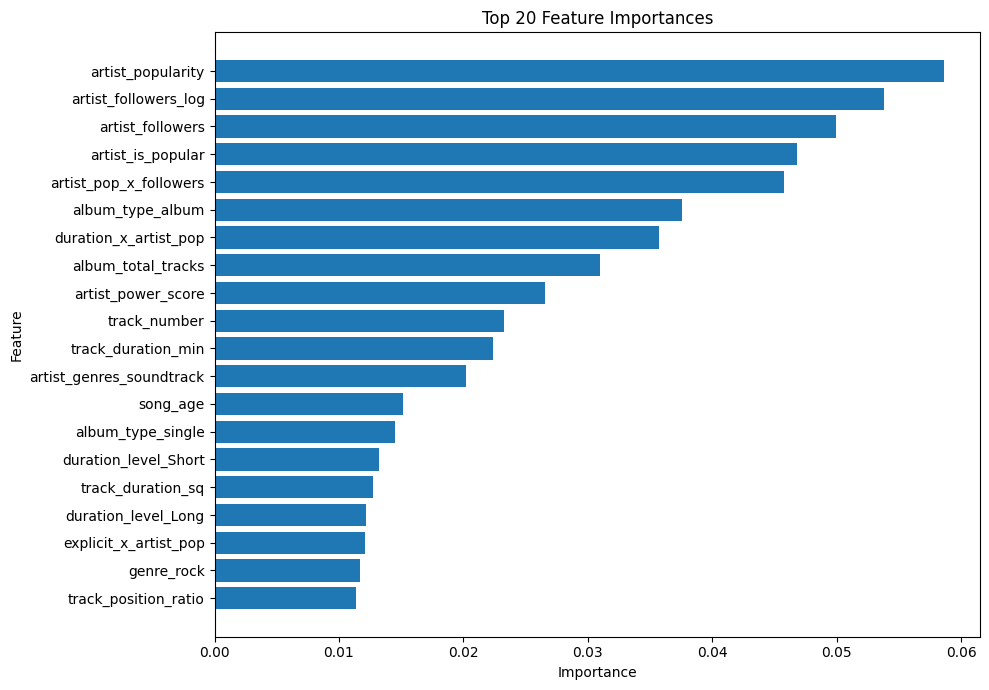

In [85]:
# =========================================================
# GET FEATURE NAMES AFTER PREPROCESSING
# =========================================================

ohe = rf_pipe.named_steps["pre"].named_transformers_["cat"]

cat_feature_names = ohe.get_feature_names_out(categorical_cols)

all_feature_names = (
    numeric_cols +
    list(cat_feature_names)
)

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importances = (
    rf_pipe.named_steps["clf"]
    .feature_importances_
)

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
})

feat_imp = feat_imp.sort_values(
    by="importance",
    ascending=False
)

print(feat_imp.head(20))

# =========================================================
# PLOT TOP FEATURES
# =========================================================

top_n = 20

top_feat = feat_imp.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    top_feat["feature"][::-1],
    top_feat["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Feature Importances")

plt.tight_layout()
plt.show()